# Submitting

## Read Data

In [ ]:
# import pandas
import pandas as pd

# Read data from github url
url = "https://raw.githubusercontent.com/deristnoor/python/refs/heads/master/project/Data%20Science%20%26%20Machine%20Learning/Melting%20Points/data/train.csv"
df = pd.read_csv(url)
df.head()

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Feature Engineering Derived from SMILES

In [ ]:
# Import packages from rdkit to convert SMILES to several key parameters
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, rdmolfiles, FunctionalGroups, AllChem, rdFreeSASA

In [4]:
def extract_melting_point_params(smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            results.append({'SMILES': smi, 'error': 'Invalid SMILES'})
            continue
        
        # Intermolecular forces
        hbd = rdMolDescriptors.CalcNumHBD(mol)
        hba = rdMolDescriptors.CalcNumHBA(mol)
        tpsa = Descriptors.TPSA(mol)
        
        # Molecular symmetry estimation (simplified)
        atom_ranks = Chem.CanonicalRankAtoms(mol, breakTies=False)
        is_symmetric = len(set(atom_ranks)) < mol.GetNumAtoms()
        
        # # Functional groups (count)
        # fg_list = FunctionalGroups.GetFunctionalGroupList(mol)
        # fg_count = len(fg_list)
        
        # Molecular size & surface area
        mw = Descriptors.MolWt(mol)
        mol_with_h = Chem.AddHs(mol)
        try:
            AllChem.EmbedMolecule(mol_with_h)
            radii = rdFreeSASA.classifyAtoms(mol_with_h)
            sasa = rdFreeSASA.CalcSASA(mol_with_h, radii)
        except:
            AllChem.EmbedMolecule(mol_with_h, useRandomCoords=True)
            radii = rdFreeSASA.classifyAtoms(mol_with_h)
            sasa = rdFreeSASA.CalcSASA(mol_with_h, radii)
        # except:
            # sasa = None
        
        # Molecular shape (branching)
        degrees = [atom.GetDegree() for atom in mol.GetAtoms()]
        branching = sum([1 for d in degrees if d > 2])  # count of branching atoms
        bertz = Descriptors.BertzCT(mol)
        
        results.append({
            'SMILES': smi,
            'H_bond_donors': hbd,
            'H_bond_acceptors': hba,
            'TPSA': tpsa,
            'Is_symmetric': is_symmetric,
            # 'Functional_groups_count': fg_count,
            'Molecular_weight': mw,
            'Surface_area_SASA': sasa,
            'Branching_atoms_count': branching,
            'Bertz_complexity': bertz
        })
    return results

In [ ]:
# DataFrame for key parameters derived from SMILES
key_parameter = pd.DataFrame(extract_melting_point_params(df.SMILES))

[16:39:58] UFFTYPER: Unrecognized charge state for atom: 1
[16:40:00] UFFTYPER: Unrecognized charge state for atom: 1
[16:40:00] 

****
Pre-condition Violation
No conformers in molecule
Violation occurred on line 134 in file /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_cc31tg3xk1/croot/rdkit_1756889094513/work/External/FreeSASA/RDFreeSASA.cpp
Failed Expression: mol.getNumConformers()
****

[16:40:04] 

****
Pre-condition Violation
No conformers in molecule
Violation occurred on line 134 in file /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_cc31tg3xk1/croot/rdkit_1756889094513/work/External/FreeSASA/RDFreeSASA.cpp
Failed Expression: mol.getNumConformers()
****

[16:40:05] UFFTYPER: Unrecognized charge state for atom: 1
[16:40:05] UFFTYPER: Unrecognized charge state for atom: 2
[16:40:07] UFFTYPER: Unrecognized charge state for atom: 2
[16:40:12] UFFTYPER: Unrecognized charge state for atom: 1


## EDA Key Parameters

In [ ]:
# Import matplotlib for visualization
from matplotlib import pyplot as plt

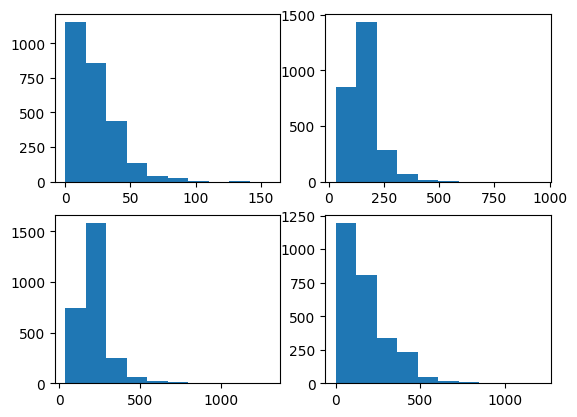

In [45]:
# Distribution of targets
fig, ax = plt.subplots(2, 2)
ax[0,0].hist(key_parameter['TPSA'])
ax[0,1].hist(key_parameter['Molecular_weight'])
ax[1,0].hist(key_parameter['Surface_area_SASA'])
ax[1,1].hist(key_parameter['Bertz_complexity'])

plt.show()

## Combined Data Feature Group and Key Parameters

In [ ]:
# Combine the initial dataframe and key parameters derived from SMILES
combined = df.merge(key_parameter, left_on="SMILES", right_on="SMILES")
combined

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 423,Group 424,H_bond_donors,H_bond_acceptors,TPSA,Is_symmetric,Molecular_weight,Surface_area_SASA,Branching_atoms_count,Bertz_complexity
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0.00,True,162.032,123.842089,4,179.793356
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,1,0,15.79,False,217.271,255.375089,6,833.661406
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,2,17.82,False,160.220,227.674007,4,401.130826
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,1,1,37.30,False,84.074,119.413843,1,104.451830
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,1,1,0.00,False,118.245,200.453758,1,33.161259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,707,ClCCBr,256.45,0,1,0,0,0,0,0,...,0,0,0,0,0.00,False,143.411,105.229145,0,8.000000
2658,1573,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,...,0,0,0,1,23.79,True,144.388,94.734410,1,75.774438
2659,1634,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,...,0,0,0,0,0.00,False,156.228,222.507954,4,413.307866
2660,3022,CCC(=O)c1ccc2ccccc2c1,333.15,1,1,0,0,0,0,0,...,0,0,0,1,17.07,False,184.238,242.503916,4,471.374187


## Data Splitting

In [ ]:
# import train test split for splitting training and test data
from sklearn.model_selection import train_test_split

In [ ]:
# Splitting features and target
X_com = combined.drop(["id","SMILES", "Tm"], axis=1)
y = combined.Tm

# Splitting training and test data
X_com_train, X_com_test, y_train, y_test = train_test_split(
    X_com,
    y,
    # stratify=y,
    test_size=0.2,
    random_state=0
)

## Base Model Selection

In [ ]:
# import ML models
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge, Lasso, ElasticNet, SGDRegressor,HuberRegressor, TheilSenRegressor, RANSACRegressor,BayesianRidge, ARDRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor)
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Regressor list for dataframe
regressors = [
    "LinearRegression", 
    "HuberRegressor", 
    "Ridge", 
    "Lasso", 
    "ElasticNet", 
    "SGDRegressor",
    # "TheilSenRegressor", 
    "RANSACRegressor",
    "BayesianRidge", 
    "ARDRegression",
    "DecisionTreeRegressor",
    "RandomForestRegressor", 
    "ExtraTreesRegressor", 
    "GradientBoostingRegressor",
    "SVR",
    "LinearSVR",
    "KNeighborsRegressor",
    "MLPRegressor",
    "LGBMRegressor",
    "CatBoostRegressor",
    "XGBRegressor"
]

# models list for dataframe
models = [
    LinearRegression(),
    HuberRegressor(), 
    Ridge(random_state=0), 
    Lasso(random_state=0), 
    ElasticNet(random_state=0), 
    SGDRegressor(random_state=0),
    # TheilSenRegressor(random_state=0), 
    RANSACRegressor(random_state=0),
    BayesianRidge(), 
    ARDRegression(),
    DecisionTreeRegressor(random_state=0),
    RandomForestRegressor(random_state=0), 
    ExtraTreesRegressor(random_state=0), 
    GradientBoostingRegressor(random_state=0),
    SVR(),
    LinearSVR(random_state=0),
    KNeighborsRegressor(),
    MLPRegressor(random_state=0),
    LGBMRegressor(random_state=0),
    CatBoostRegressor(random_state=0),
    XGBRegressor(random_state=0)
]

In [ ]:
# Dataframe creation for regressor list and base model list
Score = pd.DataFrame({"Regressor":regressors})

# fitting all base models
j = 0
mae = []
for i in models:
    model = i
    model.fit(X_com_train,y_train)
    predictions = model.predict(X_com_test)
    mae.append(mean_absolute_error(y_test,predictions))
    j = j+1     

# Scoring results for all base models to determine the best model
Score["MAE"] = mae
Score.sort_values(by="MAE",inplace = True)
Score.reset_index(drop=True, inplace=True)
Score

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1230
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 87
[LightGBM] [Info] Start training from score 277.872491
Learning rate set to 0.046135
0:	learn: 82.4266023	total: 4.59ms	remaining: 4.58s
1:	learn: 80.9574568	total: 8.65ms	remaining: 4.32s
2:	learn: 79.6156476	total: 13.1ms	remaining: 4.36s
3:	learn: 78.2816798	total: 17.5ms	remaining: 4.36s
4:	learn: 76.8957172	total: 21.8ms	remaining: 4.34s
5:	learn: 75.7989848	total: 26.2ms	remaining: 4.33s
6:	learn: 74.7315276	total: 30.5ms	remaining: 4.33s
7:	learn: 73.7404029	total: 34.8ms	remaining: 4.32s
8:	learn: 72.6811748	total: 38.5ms	remaining: 4.24s
9:	learn: 71.6951017	total: 42.3ms	remaining: 4.18s
10:	learn: 70.7362311	total

,Regressor,MAE
0,SGDRegressor,3.445271e+13
1,SVR,5.280254e+01
2,KNeighborsRegressor,4.762624e+01
3,HuberRegressor,4.542998e+01
4,ElasticNet,4.353394e+01
5,DecisionTreeRegressor,4.338844e+01
6,RANSACRegressor,4.188233e+01
7,Lasso,4.158393e+01
8,LinearSVR,4.145443e+01
9,MLPRegressor,3.804570e+01


## Base Model Selection with Scaling

In [ ]:
# Import scaler
from sklearn.preprocessing import StandardScaler

# Features that will be scaled
feature_scaled = ['TPSA','Molecular_weight','Surface_area_SASA','Bertz_complexity']

# Separate features to normalize and others in train set
X_com_train_normalize = X_com_train[feature_scaled]
X_com_train_other = X_com_train.drop(columns=feature_scaled)

# Fit scaler on training data only
scaler = StandardScaler()
X_com_train_normalized = scaler.fit_transform(X_com_train_normalize)

# Transform test set using the same scaler
X_com_test_normalize = X_com_test[feature_scaled]
X_com_test_other = X_com_test.drop(columns=feature_scaled)
X_com_test_normalized = scaler.transform(X_com_test_normalize)

# Convert scaled arrays back to DataFrames for easier handling
X_com_train_normalized_df = pd.DataFrame(X_com_train_normalized, columns=feature_scaled, index=X_com_train.index)
X_com_test_normalized_df = pd.DataFrame(X_com_test_normalized, columns=feature_scaled, index=X_com_test.index)

# Combine normalized and non-normalized features back
X_com_train_final = pd.concat([X_com_train_other, X_com_train_normalized_df], axis=1)
X_com_test_final = pd.concat([X_com_test_other, X_com_test_normalized_df], axis=1)

In [ ]:
# Dataframe creation for regressor list and base model list
Score_scaled = pd.DataFrame({"Regressor":classifiers})

# fitting all base models
j = 0
mae = []
for i in models:
    model = i
    model.fit(X_com_train_final,y_train)
    predictions = model.predict(X_com_test_final)
    mae.append(mean_absolute_error(y_test,predictions))
    j = j+1     

# Scoring results for all base models to determine the best model
Score_scaled["MAE"] = mae
Score_scaled.sort_values(by="MAE", ascending=False,inplace = True)
Score_scaled.reset_index(drop=True, inplace=True)
Score_scaled

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1231
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 87
[LightGBM] [Info] Start training from score 277.872491
Learning rate set to 0.046135
0:	learn: 82.4266023	total: 5.41ms	remaining: 5.4s
1:	learn: 80.9574568	total: 9.85ms	remaining: 4.91s
2:	learn: 79.6156476	total: 14.2ms	remaining: 4.71s
3:	learn: 78.2816798	total: 19ms	remaining: 4.72s
4:	learn: 76.8957172	total: 23.8ms	remaining: 4.74s
5:	learn: 75.7989848	total: 28.5ms	remaining: 4.71s
6:	learn: 74.7315276	total: 33.7ms	remaining: 4.78s
7:	learn: 73.7404029	total: 39.1ms	remaining: 4.85s
8:	learn: 72.6811748	total: 44.6ms	remaining: 4.92s
9:	learn: 71.6951017	total: 49.5ms	remaining: 4.9s
10:	learn: 70.7362311	total: 54

,Regressor,MAE
0,SVR,48.005883
1,ElasticNet,45.900548
2,DecisionTreeRegressor,44.484784
3,Lasso,42.163912
4,RANSACRegressor,41.882328
5,SGDRegressor,39.857703
6,LinearSVR,38.114522
7,KNeighborsRegressor,37.989066
8,GradientBoostingRegressor,36.681674
9,LinearRegression,35.799375


## Catboost Hyperparameter Tuning with GridSearchCV

In [ ]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Variable for CatBoostRegressor parameter
param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.03, 0.05],
    'iterations': [500, 1000],
    'l2_leaf_reg': [3, 5]
}

# GridSearchCV model
grid = GridSearchCV(
    CatBoostRegressor(allow_writing_files=False,verbose=False),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1
)

# Fitting the model
grid.fit(X_com_train, y_train)

# The best parameter
print(grid.best_params_)

{'depth': 8, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}


In [17]:
model_final = CatBoostRegressor(
    allow_writing_files=False,
    depth=8,
    iterations=1000,
    l2_leaf_reg=3,
    learning_rate=0.05,
    eval_metric ='MAE',
    random_state=0
)
model_final.fit(X_com_train, y_train)
predictions = model_final.predict(X_com_test)
score_final = mean_absolute_error(y_test,predictions)
score_final

0:	learn: 63.0074133	total: 4.09ms	remaining: 4.09s
1:	learn: 61.4873476	total: 6.47ms	remaining: 3.23s
2:	learn: 60.0022135	total: 8.51ms	remaining: 2.83s
3:	learn: 58.6164197	total: 14.1ms	remaining: 3.52s
4:	learn: 57.3792468	total: 18.5ms	remaining: 3.69s
5:	learn: 56.1574205	total: 21ms	remaining: 3.48s
6:	learn: 55.0014244	total: 22.8ms	remaining: 3.23s
7:	learn: 53.9017958	total: 24.6ms	remaining: 3.06s
8:	learn: 52.8353373	total: 26.4ms	remaining: 2.9s
9:	learn: 52.0943497	total: 28.3ms	remaining: 2.8s
10:	learn: 51.2544514	total: 30ms	remaining: 2.7s
11:	learn: 50.4162505	total: 31.6ms	remaining: 2.6s
12:	learn: 49.5270744	total: 33.3ms	remaining: 2.53s
13:	learn: 48.8951339	total: 34.9ms	remaining: 2.46s
14:	learn: 48.1424756	total: 36.5ms	remaining: 2.39s
15:	learn: 47.5642990	total: 38ms	remaining: 2.34s
16:	learn: 46.9119308	total: 39.9ms	remaining: 2.31s
17:	learn: 46.2964541	total: 42.4ms	remaining: 2.31s
18:	learn: 45.7435759	total: 44.3ms	remaining: 2.29s
19:	learn: 45

31.57645304070537

## Catboost Regressor Hyperparameter Tuning with Optuna

In [ ]:
# Splitting the data for training and test data
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_com, y, test_size=0.2, random_state=0
)

# Spliting the training data for training and validation data
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=0
)

In [ ]:
# Import Optiuna and optuna integration
import optuna
from optuna.integration import CatBoostPruningCallback


def objective(trial):

    # Parameters for CatBoostRegressor
    params = {
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "iterations": 2000,  # Early stopping handles it
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 20, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise"]),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "border_count": trial.suggest_int("border_count", 64, 255),
        "task_type": "CPU",
        "verbose": 0
    }

    # Create the model
    model = CatBoostRegressor(**params, allow_writing_files=False)

    # Fitting the model
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=200,
        verbose=False
    )

    # Prediction and Scoring
    preds = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, preds)

    return mae

In [ ]:
# Make study optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Get best parameters
best_params = study.best_params
print(f"Best MAE: {study.best_value}")
print(f"Best parameters: {best_params}")

[I 2025-11-21 16:55:40,683] A new study created in memory with name: no-name-2080de5e-326b-41c6-afb0-d831cf8d3e02


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-21 16:55:44,050] Trial 0 finished with value: 31.777247743631268 and parameters: {'learning_rate': 0.04188625773477863, 'depth': 10, 'l2_leaf_reg': 0.012421187003708749, 'random_strength': 0.0016598116643145354, 'bagging_temperature': 2.9148082428255457, 'min_data_in_leaf': 18, 'grow_policy': 'SymmetricTree', 'subsample': 0.7954484778195762, 'border_count': 234}. Best is trial 0 with value: 31.777247743631268.
[I 2025-11-21 16:55:44,935] Trial 1 finished with value: 30.546655782898913 and parameters: {'learning_rate': 0.05416931082303399, 'depth': 5, 'l2_leaf_reg': 9.737858589343164, 'random_strength': 0.004234859977284827, 'bagging_temperature': 3.58661708002911, 'min_data_in_leaf': 1, 'grow_policy': 'SymmetricTree', 'subsample': 0.9213967346623071, 'border_count': 235}. Best is trial 1 with value: 30.546655782898913.
[I 2025-11-21 16:55:46,311] Trial 2 finished with value: 31.159942449289616 and parameters: {'learning_rate': 0.10046261162923119, 'depth': 9, 'l2_leaf_reg': 

In [ ]:
# Final model with the best parameters
final_model = CatBoostRegressor(
    allow_writing_files=False,
    loss_function="MAE",
    eval_metric="MAE",
    iterations=2000,
    task_type="CPU",
    verbose=100,
    **best_params
)

# Fitting the final model
final_model.fit(
    X_train_full, y_train_full,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=200
)

0:	learn: 62.8775820	test: 60.1896974	best: 60.1896974 (0)	total: 4.45ms	remaining: 8.89s
100:	learn: 31.2301798	test: 29.7698323	best: 29.7698323 (100)	total: 79.8ms	remaining: 1.5s
200:	learn: 26.8554780	test: 25.5546298	best: 25.5546298 (200)	total: 149ms	remaining: 1.33s
300:	learn: 24.7880785	test: 23.6693644	best: 23.6693644 (300)	total: 220ms	remaining: 1.24s
400:	learn: 23.5767007	test: 22.3550562	best: 22.3550562 (400)	total: 295ms	remaining: 1.18s
500:	learn: 22.6389433	test: 21.5559066	best: 21.5559066 (500)	total: 365ms	remaining: 1.09s
600:	learn: 21.7167854	test: 20.5441901	best: 20.5441901 (600)	total: 435ms	remaining: 1.01s
700:	learn: 21.0955744	test: 19.9979910	best: 19.9979910 (700)	total: 504ms	remaining: 933ms
800:	learn: 20.5400915	test: 19.4918239	best: 19.4918239 (800)	total: 578ms	remaining: 866ms
900:	learn: 20.1280862	test: 19.1664065	best: 19.1664065 (900)	total: 670ms	remaining: 817ms
1000:	learn: 19.6734182	test: 18.6712105	best: 18.6712105 (1000)	total: 7

In [ ]:
# Predict the test data on final model
test_preds = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_preds)

# Test MAE
print("FINAL TEST MAE:", test_mae)

FINAL TEST MAE: 30.11198643505984


# Test Data

## Read Data

In [ ]:
# Read test data via github link
url = "https://raw.githubusercontent.com/deristnoor/python/refs/heads/master/project/Data%20Science%20%26%20Machine%20Learning/Melting%20Points/data/test.csv"
test_sample = pd.read_csv(url)

,id,SMILES,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,1022,CCOC(=O)c1ccc(O)cc1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1146,CCCCCCc1ccc(O)cc1O,1,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79,ClCBr,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2279,C=CCCCCCCCC,1,7,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1342,Fc1ccc(cc1)C(F)(F)F,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,2663,CCCCCCCCC(=O)CC,2,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
662,624,COc1ccc(COC(=O)C)cc1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
663,2655,C#CCCC(C)C,2,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
664,2089,BrCC(Br)C(Br)C,1,1,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Key Parameter for Test Data

In [ ]:
# Derived the key parameter from SMILES
key_parameter_test_sample = pd.DataFrame(extract_melting_point_params(test_sample.SMILES))

# Combined the test data with the key parameter derived from SMILES
combined_test_sample = test_sample.merge(key_parameter_test_sample, left_on="SMILES", right_on="SMILES")
combined_test_sample

[17:04:54] UFFTYPER: Unrecognized charge state for atom: 1


## Melting Point Prediction on Test Data

In [ ]:
# Prediction on test data
X_test_sample = combined_test_sample.drop(columns=['id','SMILES'])
pred_test_sample = final_model.predict(X_test_sample)

# Prediction result
submission_test = test_sample[['id','SMILES']].copy()
submission_test['Tm'] = pred_test_sample
submission_test.head()

,id,SMILES,Tm
0,1022,CCOC(=O)c1ccc(O)cc1,338.314206
1,1146,CCCCCCc1ccc(O)cc1O,331.272001
2,79,ClCBr,206.426660
3,2279,C=CCCCCCCCC,194.568445
4,1342,Fc1ccc(cc1)C(F)(F)F,247.122127


In [ ]:
# Prediction submission
submission = submission_test[['id', 'Tm']]
submission.to_csv(path_or_buf="/Users/deris/Downloads/submission.csv", index=False)
submission.head()

,id,Tm
0,1022,338.314206
1,1146,331.272001
2,79,206.426660
3,2279,194.568445
4,1342,247.122127


## Melting Points Reference from Jean-Claude Bradley Open Melting Point Dataset

In [ ]:
# Read Jean-Claude Bradley Open Melting Point Dataset via github link
url = "https://github.com/deristnoor/python/raw/refs/heads/master/project/Data%20Science%20&%20Machine%20Learning/Melting%20Points/data/BradleyMeltingPointDataset.xlsx"
bradley_melting_points = pd.read_excel(url)
bradley_melting_points.head()



,key,name,smiles,mpC,csid,link,source,donotuse,donotusebecause
0,1,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,64018,http://www.alfa.com/en/GP100W.pgm?DSSTK=B24192,Alfa Aesar,NaN,NaN
1,2,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,403764,http://www.alfa.com/en/GP100W.pgm?DSSTK=A13073,Alfa Aesar,NaN,NaN
2,3,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,80080,http://www.alfa.com/en/GP100W.pgm?DSSTK=L15884,Alfa Aesar,NaN,NaN
3,4,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,63701,http://www.alfa.com/en/GP100W.pgm?DSSTK=B20252,Alfa Aesar,NaN,NaN
4,5,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,69388,http://www.alfa.com/en/GP100W.pgm?DSSTK=L08261,Alfa Aesar,NaN,NaN


In [ ]:
# Select only necessary feature from the data
mp_ref = bradley_melting_points[['smiles', "mpC"]]
mp_ref['Tm_bradley'] = mp_ref['mpC']+273.15
mp_ref

,smiles,mpC,Tm_bradley
0,c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,365.15
1,c1ccc(c(c1)N)N2CCCCC2,46.0,319.15
2,c1cnc(nc1)N2CCNCC2,33.0,306.15
3,c1ccc(c(c1)N2CCNCC2)O,125.0,398.15
4,C1CCC(=CC1)CCN,-55.0,218.15
...,...,...,...
28640,c1ccc2c(c1)Cc3ccccc3O2,100.5,373.65
28641,c1ccc2c(c1)Cc3ccccc3O2,100.5,373.65
28642,c1ccc2c(c1)Cc3ccccc3O2,101.5,374.65
28643,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0,374.15


In [ ]:
# Combined available reference dataset with the prediction result
test_combined = mp_ref.merge(submission_test, left_on='smiles', right_on='SMILES', how="inner")
test_combined

,smiles,mpC,Tm_bradley,id,SMILES,Tm
0,CCOCCOCC,-74.0,199.15,2055,CCOCCOCC,197.834967
1,CC(C)CC(C)(C)C,-107.0,166.15,1539,CC(C)CC(C)(C)C,167.495350
2,CC(C)CC(C)C,-123.0,150.15,749,CC(C)CC(C)C,156.815879
3,CC#CC#CC,67.0,340.15,2752,CC#CC#CC,182.921437
4,c1ccc(cc1)c2cccc(n2)c3ccccc3,78.0,351.15,2831,c1ccc(cc1)c2cccc(n2)c3ccccc3,394.040985
...,...,...,...,...,...,...
471,c1ccc2ccccc2c1,80.0,353.15,343,c1ccc2ccccc2c1,290.053579
472,c1ccc2ccccc2c1,80.0,353.15,343,c1ccc2ccccc2c1,290.053579
473,c1ccc2ccccc2c1,82.0,355.15,343,c1ccc2ccccc2c1,290.053579
474,CCC(=O)O,-20.7,252.45,215,CCC(=O)O,269.917240


In [ ]:
# MAE score predicted value with reference dataset
test_mae = mean_absolute_error(test_combined['Tm_bradley'], test_combined['Tm'])
test_mae

28.50160304046673